# Tanzania Food Demand and Nutritional Adequacy

This notebook estimates a Constant Frisch Elasticity (CFE) demand system and discusses the landscape of the nutritional diet and its adequacy using household food expenditure data from Tanzania (2019–20 and 2020–21 survey waves).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cfe import Regression
import cfe

### Data [A]

The data is stored in a local Excel file (`Tanzania.xlsx`) with the following sheets:

- **Household Characteristics** — one row per household-wave, with demographic columns (household members by age/sex group and log household size).
- **Food Expenditures (2019-20)** and **Food Expenditures (2020-21)** — long-format records of household food expenditures, one row per household–food pair.

All sheets share the index columns `i` (household ID), `t` (survey wave), and `m` (market/region).

### Load raw sheets

In [2]:
DATA_FILE = 'Tanzania.xlsx'

# Household characteristics (filter to the two survey waves that have expenditure data)
d_raw = pd.read_excel(DATA_FILE, sheet_name='Household Characteristics')

# Food expenditures — two survey waves loaded separately and concatenated
x_raw_2019 = pd.read_excel(DATA_FILE, sheet_name='Food Expenditures (2019-20)')
x_raw_2020 = pd.read_excel(DATA_FILE, sheet_name='Food Expenditures (2020-21)')
x_raw = pd.concat([x_raw_2019, x_raw_2020], ignore_index=True)

print(f"Household characteristics rows : {len(d_raw):,}")
print(f"Food expenditure records       : {len(x_raw):,}")
print(f"Unique foods                   : {x_raw['j'].nunique()}")
print(f"Survey waves                   : {sorted(x_raw['t'].unique())}")

Household characteristics rows : 22,433
Food expenditure records       : 21,309
Unique foods                   : 59
Survey waves                   : ['2019-20', '2020-21']


### Household characteristics dataframe (d)
Missing values in demographic columns are treated as zero (no members of that age/sex group).

In [12]:
# Keep only waves that have matching expenditure data
WAVES = ['2019-20', '2020-21']
d = d_raw[d_raw['t'].isin(WAVES)].copy()

# Consistency string dtypes across columns
for col in ['i', 't', 'm']:
    d[col] = d[col].astype(str)

d.columns.name = 'k'
d.set_index(['i', 't', 'm'], inplace=True)
d = d.fillna(0) 

print(f"d shape: {d.shape}")
d.head()

d shape: (5893, 15)


,,k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize
i,t,m,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.693147
0001-001-003,2019-20,Mainland Rural,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000
0001-001-004,2019-20,Dar Es Salaam,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.000000
0001-004-001,2019-20,Mainland Rural,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1.098612
0001-004-002,2019-20,Mainland Other Urban,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.000000


### Log-expenditure dataframe (y)

In [13]:
# Consistent string dtypes
for col in ['i', 't', 'm']:
    x_raw[col] = x_raw[col].astype(str)

# One column per food item
x = x_raw.pivot_table(
    index=['i', 't', 'm'],
    columns='j',
    values='Expenditure',
    aggfunc='sum'
)
x = x.replace(0, np.nan)  # Replace zeros with missing before taking logs
y = np.log(x)

print(f"y shape (households × foods): {y.shape}")
y.head()

y shape (households × foods): (1516, 59)


,,j,Beef,Bottled Beer,Bread,"Buns, Cakes And Biscuits","Butter, Etc.",Cassava Dry/Flour,Cassava Fresh,Chicken,Citrus Fruits,Coconuts,...,Sugarcane,Sweet Potatoes,Sweets,Tea (dry),Vegetables (fresh),Vegetables (preserved),Wheat Flour,Wild Birds & Insects,Wine & Spirits,Yams/Cocoyams
i,t,m,,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,NaN,NaN,NaN,NaN,NaN,NaN,7.313220,9.249561,NaN,NaN,...,NaN,NaN,NaN,4.787492,7.901007,NaN,NaN,NaN,NaN,NaN
0001-001-003,2019-20,Mainland Rural,8.006368,NaN,NaN,NaN,NaN,NaN,7.052937,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.540356,NaN,NaN,NaN,NaN,NaN
0001-001-004,2019-20,Dar Es Salaam,NaN,NaN,NaN,7.302496,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6.273551,NaN,5.298317,7.042003,NaN,NaN,NaN,NaN,NaN
0001-004-001,2019-20,Mainland Rural,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7.531910,NaN,5.347108,7.150701,NaN,NaN,NaN,NaN,NaN
0001-004-002,2019-20,Mainland Other Urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.139101,NaN,NaN,NaN,NaN,NaN


### Re-format for regression

In [5]:
y = y.stack().dropna()
d = d.stack().dropna()

# Verify index structure
assert y.index.names == ['i', 't', 'm', 'j'], f"Unexpected y index: {y.index.names}"
assert d.index.names == ['i', 't', 'm', 'k'], f"Unexpected d index: {d.index.names}"

print(f"y observations : {len(y):,}")
print(f"d observations : {len(d):,}")

y observations : 21,309
d observations : 88,395


## Fit Regression Model

In [6]:
result = Regression(y=y, d=d)

In [7]:
result.predicted_expenditures()

i             t        m                     j                       
0001-001-001  2019-20  Mainland Rural        Beef                        6225.450559
                                             Bread                       1885.505572
                                             Buns, Cakes And Biscuits    1717.544391
                                             Cassava Fresh               2016.274266
                                             Chicken                     8141.135094
                                                                            ...     
9808-001-99   2020-21  Mainland Other Urban  Sugar                       2853.439504
                                             Sweet Potatoes              2360.359148
                                             Tea (dry)                    509.822159
                                             Vegetables (fresh)          2227.879537
                                             Wheat Flour                 2232.52

### Predicted vs. actual log expenditures plot

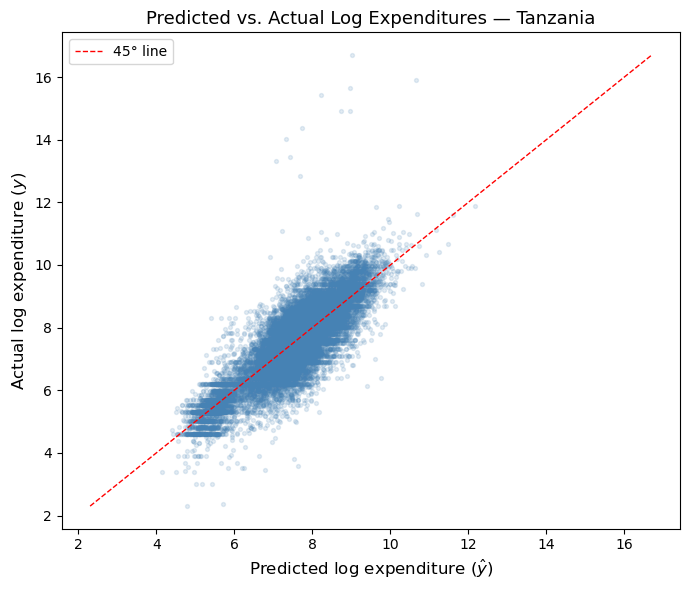

In [8]:
%matplotlib inline

df_fit = pd.DataFrame({
    'y'   : y,
    'yhat': result.get_predicted_log_expenditures()
})

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_fit['yhat'], df_fit['y'], alpha=0.15, s=8, color='steelblue')

# 45-degree reference line
lims = [df_fit[['y', 'yhat']].min().min(), df_fit[['y', 'yhat']].max().max()]
ax.plot(lims, lims, 'r--', linewidth=1, label='45° line')

ax.set_xlabel('Predicted log expenditure ($\\hat{y}$)', fontsize=12)
ax.set_ylabel('Actual log expenditure ($y$)', fontsize=12)
ax.set_title('Predicted vs. Actual Log Expenditures — Tanzania', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

This graph shows only in-sample fit so it doesn't really help us that much. Could probably be improved by predicting fit on one wave using data from another. However, even with that, it wouldn't be useful since COVID-19 changed the outcomes.

## 4. Demand System [A]

### Frisch elasticities

The coefficients represent how income-elastic each food is. Higher values mean that a good's expenditure share rises more with total expenditure (it is more of a "luxury" within the food budget). Lower values indicates necessities that are always in demand regardless of price.

In [9]:
result.get_beta().sort_values()

j
Other Spices                0.085157
Fish (dried)                0.097858
Maize (flour)               0.163674
Salt                        0.219309
Chicken                     0.228003
Eggs                        0.302643
Bread                       0.346234
Cooking Oil                 0.346325
Rice (husked)               0.355506
Macaroni, Spaghetti         0.359340
Sugar                       0.363795
Pulses                      0.380210
Tea (dry)                   0.382893
Beef                        0.394625
Wheat Flour                 0.395246
Coconuts                    0.460999
Buns, Cakes And Biscuits    0.491180
Soft drinks                 0.491544
Irish Potatoes              0.491682
Milk (fresh)                0.514590
Fish (fresh)                0.519063
Vegetables (fresh)          0.528931
Cassava Fresh               0.582213
Sweet Potatoes              0.627395
Plantains                   0.668549
Leafy Greens                0.696915
Other Fruits                1.047823

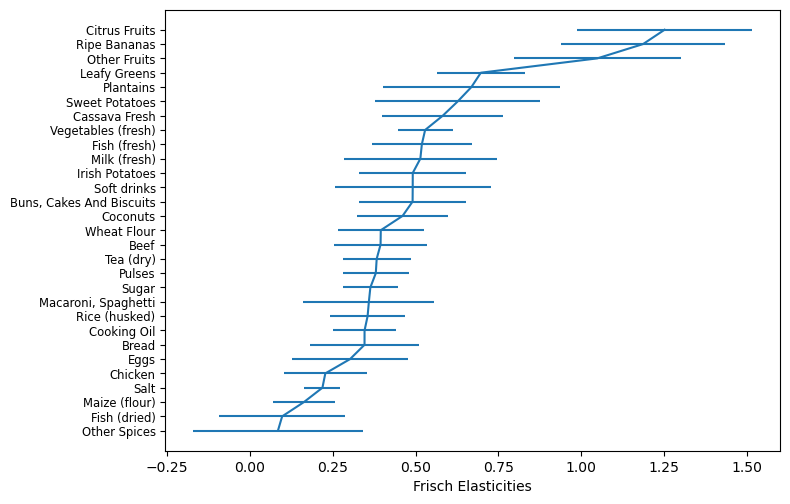

In [10]:
result.graph_beta()
plt.show()

As you can see, the important staple foods that are crucial for survival are those in the bottom left of the graph with low elasticities: households need these goods no matter what.

On the opposite end of the graph, we see foods like citrus and other fruits which tend to be more expensive. Since these have higher Frisch elasticities, these are the first to go when income fluctuates and are often crowded out by the cheaper staple foods.

### 4.2 Household composition effects

These numbers summarize how household demographic composition shifts demand for each food, based on total expenditure. Each row is a food; each column is a demographic characteristic.

In [11]:
result.gamma

k,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,
Beef,0.077682,-0.005968,0.111223,-0.013025,-0.192215,-0.109427,0.005910,0.061885,0.004780,0.036174,0.161237,0.151777,0.195287,0.127008,0.230110,8.757647
Bread,-0.144494,-0.106851,-0.013777,0.148933,0.132345,0.148128,-0.048996,0.088761,0.002687,0.100339,0.229477,0.060044,0.103132,0.295171,0.069250,7.709530
"Buns, Cakes And Biscuits",0.010819,-0.036685,-0.028856,-0.078656,0.087289,0.020987,0.065805,0.226198,-0.045866,-0.002440,0.033185,-0.064457,0.077756,-0.037615,0.397207,7.433694
Cassava Fresh,0.026137,0.062127,-0.000151,0.019185,0.070276,0.133597,0.071796,-0.072334,0.096153,-0.030905,0.012677,-0.031762,0.055274,0.217517,0.290560,7.510538
Chicken,0.031111,-0.132517,0.080621,0.091843,-0.079714,0.096516,-0.255527,-0.074955,-0.156359,0.004110,-0.095286,0.001454,-0.005707,0.034354,0.455818,9.049572
Citrus Fruits,-0.270057,-0.083495,-0.253770,0.044515,0.045555,-0.095496,0.075231,-0.019145,-0.074248,-0.113014,-0.084554,-0.124245,-0.254391,0.130596,0.576627,6.905943
Coconuts,-0.081598,-0.101330,-0.007152,0.000079,-0.028668,0.004202,-0.072938,0.018634,-0.005096,0.008348,-0.034155,-0.036708,0.108692,0.113382,0.440262,7.847034
Cooking Oil,-0.072479,-0.025707,-0.134748,-0.048658,-0.025759,-0.022279,0.068460,0.029011,-0.013321,0.158009,0.122801,0.144997,-0.028088,0.019905,0.269062,7.413332
Eggs,-0.190926,0.018887,0.118880,0.034417,-0.112722,0.174081,-0.055745,0.059651,0.030172,0.170285,0.192240,0.084080,-0.035207,0.125922,0.133956,7.422005


Here is the summarized household composition effects of demand, showing elasticities for each food based on age/sex group, also including a column for the effect of household size.

A few interesting trends stand out:
- Household size seems to be dominant driver in elasticity changes, having a much larger mean effect than any one age/sex group. This effect difference varies greatly between foods however, with the data suggesting that larger households tend to concentrate spending on staples rather than convenience foods.

- Older women (51+) show the strongest positive demographic effect on traditional staple foods, likely reflecting their role as the primary food decision-makers and a preference for traditional dietary patterns.

- Young children tend to suppress protein-rich and nutrient-dense food which is concerning.

- Teenage girls have the strongest positive demographic effect for most processed and convenience foods which is also concerning.

There seems to be systemic nutritional tensions between the people making food-decisions (working age men and older women) and the people who are most nutritionally vulnerable.

## Nutritional Content of Different Foods [B]

### Identify foods and nutrient mapping

In [11]:
import re
import time
import requests
import pandas as pd
import numpy as np

# Foods from the final CFE model
FOODS = [
    'Beef', 'Bread', 'Buns, Cakes And Biscuits', 'Cassava Fresh', 'Chicken',
    'Citrus Fruits', 'Coconuts', 'Cooking Oil', 'Eggs', 'Fish (dried)',
    'Fish (fresh)', 'Irish Potatoes', 'Leafy Greens', 'Macaroni, Spaghetti',
    'Maize (flour)', 'Milk (fresh)', 'Other Fruits', 'Other Spices',
    'Plantains', 'Pulses', 'Rice (husked)', 'Ripe Bananas', 'Salt',
    'Soft drinks', 'Sugar', 'Sweet Potatoes', 'Tea (dry)',
    'Vegetables (fresh)', 'Wheat Flour',
]

# Mapping nutrients to ids 
NUTRIENT_MAP = {
    'Energy':                          1008,  # kcal
    'Protein':                         1003,  # g
    'Fiber, total dietary':            1079,  # g
    'Folate, DFE':                     1190,  # µg
    'Calcium, Ca':                     1087,  # mg
    'Carbohydrate, by difference':     1005,  # g
    'Iron, Fe':                        1089,  # mg
    'Magnesium, Mg':                   1090,  # mg
    'Niacin':                          1167,  # mg
    'Phosphorus, P':                   1091,  # mg
    'Potassium, K':                    1092,  # mg
    'Riboflavin':                      1166,  # mg
    'Thiamin':                         1165,  # mg
    'Vitamin A, RAE':                  1106,  # µg
    'Vitamin B-12':                    1178,  # µg
    'Vitamin B-6':                     1175,  # µg
    'Vitamin C, total ascorbic acid':  1162,  # mg
    'Vitamin E (alpha-tocopherol)':    1109,  # mg
    'Vitamin K (phylloquinone)':       1185,  # µg
    'Zinc, Zn':                        1095,  # mg
}

FDC_API_KEY    = 'uOgTaIqGwW8Of1b6UcucKDg1yWcBt01FPea0hqDT'
FDC_SEARCH_URL = 'https://api.nal.usda.gov/fdc/v1/foods/search'
FDC_FOOD_URL   = 'https://api.nal.usda.gov/fdc/v1/food/{fdcId}'

### Find FDC IDs

In [12]:
# making searching the fdc database more accurate/efficient
SEARCH_OVERRIDES = {
    'Beef':                    'beef ground raw',
    'Bread':                   'bread white commercially prepared',
    'Buns, Cakes And Biscuits':'biscuits plain prepared from recipe',
    'Cassava Fresh':           'cassava raw',
    'Chicken':                 'chicken broilers or fryers meat only raw',
    'Citrus Fruits':           'oranges raw navels',
    'Coconuts':                'coconut meat raw',
    'Cooking Oil':             'oil vegetable sunflower',
    'Eggs':                    'egg whole raw fresh',
    'Fish (dried)':            'fish tilapia dried',
    'Fish (fresh)':            'fish tilapia raw',
    'Irish Potatoes':          'potatoes white flesh and skin raw',
    'Leafy Greens':            'spinach raw',
    'Macaroni, Spaghetti':     'pasta dry unenriched',
    'Maize (flour)':           'corn flour whole-grain yellow',
    'Milk (fresh)':            'milk whole 3.25% milkfat without added vitamin A and D',
    'Other Fruits':            'mixed fruit raw',
    'Other Spices':            'spices mixed',
    'Plantains':               'plantains green raw',
    'Pulses':                  'beans black mature seeds raw',
    'Rice (husked)':           'rice white long-grain regular raw unenriched',
    'Ripe Bananas':            'bananas raw',
    'Salt':                    'salt table',
    'Soft drinks':             'beverages carbonated cola regular',
    'Sugar':                   'sugars granulated',
    'Sweet Potatoes':          'sweet potato raw unprepared',
    'Tea (dry)':               'beverages tea black brewed prepared with tap water',
    'Vegetables (fresh)':      'tomatoes red ripe raw year round average',
    'Wheat Flour':             'wheat flour whole-grain',
}

def search_fdc(food_name, api_key, preferred_types=('Foundation', 'SR Legacy')):
    """Return the fdcId of the best FDC match for a food name, skipping any
    IDs that return 404 from the individual food endpoint."""
    query = SEARCH_OVERRIDES.get(food_name, food_name)
    # Strip characters the FDC API rejects and collapse whitespace (had issues with this causing errors eralier)
    query = re.sub(r'[(),]', ' ', query)
    query = re.sub(r'\s+', ' ', query).strip()

    params = {
        'query':    query,
        'dataType': ','.join(preferred_types),
        'pageSize': 5,
        'api_key':  api_key,
    }
    resp = requests.get(FDC_SEARCH_URL, params=params)
    resp.raise_for_status()
    candidates = resp.json().get('foods', [])

    for candidate in candidates:
        fdc_id = candidate['fdcId']
        check = requests.get(FDC_FOOD_URL.format(fdcId=fdc_id), params={'api_key': api_key})
        if check.status_code == 200:
            return fdc_id, candidate['description']
        elif check.status_code == 404:
            print(f"  [{food_name}] fdcId {fdc_id} returned 404, trying next candidate...")
            time.sleep(0.2)
            continue
        else:
            check.raise_for_status()

    return None, None 

# Search for all 29 foods
food_ids = {}
print(f"{'Food':<30} {'fdcId':>8}  Description")
print('-' * 80)
for food in FOODS:
    fdc_id, desc = search_fdc(food, FDC_API_KEY)
    food_ids[food] = fdc_id
    print(f"{food:<30} {str(fdc_id):>8}  {desc}")
    time.sleep(0.2)

Food                              fdcId  Description
--------------------------------------------------------------------------------
Beef                             168608  Beef, grass-fed, ground, raw
  [Bread] fdcId 325871 returned 404, trying next candidate...
Bread                            174925  Bread, white, commercially prepared, toasted
Buns, Cakes And Biscuits         172670  Biscuits, plain or buttermilk, prepared from recipe
Cassava Fresh                    169985  Cassava, raw
Chicken                          171052  Chicken, broilers or fryers, meat only, raw
  [Citrus Fruits] fdcId 746771 returned 404, trying next candidate...
Citrus Fruits                    169917  Oranges, raw, navels (Includes foods for USDA's Food Distribution Program)
Coconuts                         170169  Nuts, coconut meat, raw
Cooking Oil                     1750349  Oil, sunflower
Eggs                             171287  Egg, whole, raw, fresh
Fish (dried)                     175176  Fish

In [13]:
# final food_df with nutrients
def fetch_nutrients(fdc_id, nutrient_ids, api_key):
    """Return a dict {nutrient_name: value_per_100g} for the requested nutrient IDs."""
    url = FDC_FOOD_URL.format(fdcId=fdc_id)
    resp = requests.get(url, params={'api_key': api_key})
    resp.raise_for_status()
    data = resp.json()

    # Build a lookup: nutrient_id -> value
    id_to_value = {}
    for n in data.get('foodNutrients', []):
        nid = (n.get('nutrient') or {}).get('id') or n.get('nutrientId')
        val = n.get('amount') or n.get('value')
        if nid and val is not None:
            id_to_value[nid] = val

    return {name: id_to_value.get(nid) for name, nid in nutrient_ids.items()}

# Fetch nutrient data for every food
records = []
for food, fdc_id in food_ids.items():
    if fdc_id is None:
        print(f"WARNING: no FDC match found for '{food}', skipping.")
        continue
    nutrients = fetch_nutrients(fdc_id, NUTRIENT_MAP, FDC_API_KEY)
    nutrients['food']  = food
    nutrients['fdcId'] = fdc_id
    records.append(nutrients)
    time.sleep(0.2) # had issues with rate of requests

food_df = pd.DataFrame(records).set_index('food')
print(fdc_df.shape)
food_df

(29, 21)


,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P",...,Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn",fdcId
food,,,,,,,,,,,,,,,,,,,,,
Beef,198.0,19.42,NaN,6.0,12.0,NaN,1.99,19.0,4.818,175.0,...,0.154,0.049,NaN,1.97,0.355,NaN,0.35,1.100,4.55,168608
Bread,290.0,9.00,2.9,160.0,119.0,54.50,3.33,26.0,3.926,103.0,...,0.337,0.415,NaN,0.02,0.063,NaN,0.24,3.400,0.68,174925
"Buns, Cakes And Biscuits",353.0,7.00,1.5,95.0,235.0,44.60,2.90,18.0,2.949,164.0,...,0.310,0.356,NaN,0.08,0.035,0.2,NaN,NaN,0.54,172670
Cassava Fresh,160.0,1.36,1.8,27.0,16.0,38.06,0.27,21.0,0.854,27.0,...,0.048,0.087,1.0,NaN,0.088,20.6,0.19,1.900,0.34,169985
Chicken,119.0,21.39,NaN,7.0,12.0,NaN,0.89,25.0,8.239,173.0,...,0.142,0.073,16.0,0.37,0.430,2.3,0.21,1.800,1.54,171052
Citrus Fruits,49.0,0.91,2.2,34.0,43.0,12.54,0.13,11.0,0.425,23.0,...,0.051,0.068,12.0,NaN,0.079,59.1,0.15,NaN,0.08,169917
Coconuts,354.0,3.33,9.0,26.0,14.0,15.23,2.43,32.0,0.540,113.0,...,0.020,0.066,NaN,NaN,0.054,3.3,0.24,0.200,1.10,170169
Cooking Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.48,6.925,NaN,1750349
Eggs,143.0,12.56,NaN,47.0,56.0,0.72,1.75,12.0,0.075,198.0,...,0.457,0.040,160.0,0.89,0.170,NaN,1.05,0.300,1.29,171287


In [16]:
# Diet minimums
rdi = pd.read_csv('diet_minimums.csv', index_col=0)
rdi = rdi.set_index('Nutrition').drop(columns='Source')

# Show for F 19-30 and M 19-30
rdi_adult = rdi[['F 19-30', 'M 19-30']].apply(pd.to_numeric, errors='coerce').mean(axis=1)
rdi_adult.name = 'RDI_adult_avg'

# Nutrients per 100g
nutrient_cols  = list(NUTRIENT_MAP.keys())
food_nutrients = food_df[nutrient_cols].apply(pd.to_numeric, errors='coerce')

# % of adult RDI provided per 100g of each food
coverage_pct = food_nutrients.div(rdi_adult, axis=1) * 100
coverage_pct.columns.name = 'nutrient'
coverage_pct.index.name   = 'food'

print("% of adult RDI provided per 100g (for selected nutrients)")
display_cols = ['Energy', 'Protein', 'Iron, Fe', 'Calcium, Ca',
                'Vitamin A, RAE', 'Vitamin C, total ascorbic acid', 'Zinc, Zn']
print(coverage_pct[display_cols].round(1).to_string())

% of adult RDI provided per 100g (for selected nutrients)
nutrient                  Energy  Protein  Iron, Fe  Calcium, Ca  Vitamin A, RAE  Vitamin C, total ascorbic acid  Zinc, Zn
food                                                                                                                      
Beef                         9.0     38.1      15.3          1.2             NaN                             NaN      47.9
Bread                       13.2     17.6      25.6         11.9             NaN                             NaN       7.2
Buns, Cakes And Biscuits    16.0     13.7      22.3         23.5             NaN                             0.2       5.7
Cassava Fresh                7.3      2.7       2.1          1.6             0.1                            25.0       3.6
Chicken                      5.4     41.9       6.8          1.2             2.0                             2.8      16.2
Citrus Fruits                2.2      1.8       1.0          4.3             1.5 

Nutrients with WEAK coverage (no single food provides ≥20% RDI per 100g):
nutrient
Energy    17.5

Nutrients with GOOD coverage (≥20% RDI from at least one food):
nutrient
Vitamin K (phylloquinone)         459.9
Vitamin E (alpha-tocopherol)      456.5
Iron, Fe                          151.6
Folate, DFE                       111.0
Vitamin B-12                       82.1
Thiamin                            78.3
Carbohydrate, by difference        76.6
Vitamin C, total ascorbic acid     71.6
Calcium, Ca                        68.2
Vitamin A, RAE                     58.6
Niacin                             54.9
Fiber, total dietary               50.3
Phosphorus, P                      50.3
Magnesium, Mg                      48.2
Zinc, Zn                           47.9
Protein                            42.4
Riboflavin                         38.1
Vitamin B-6                        33.1
Potassium, K                       31.6


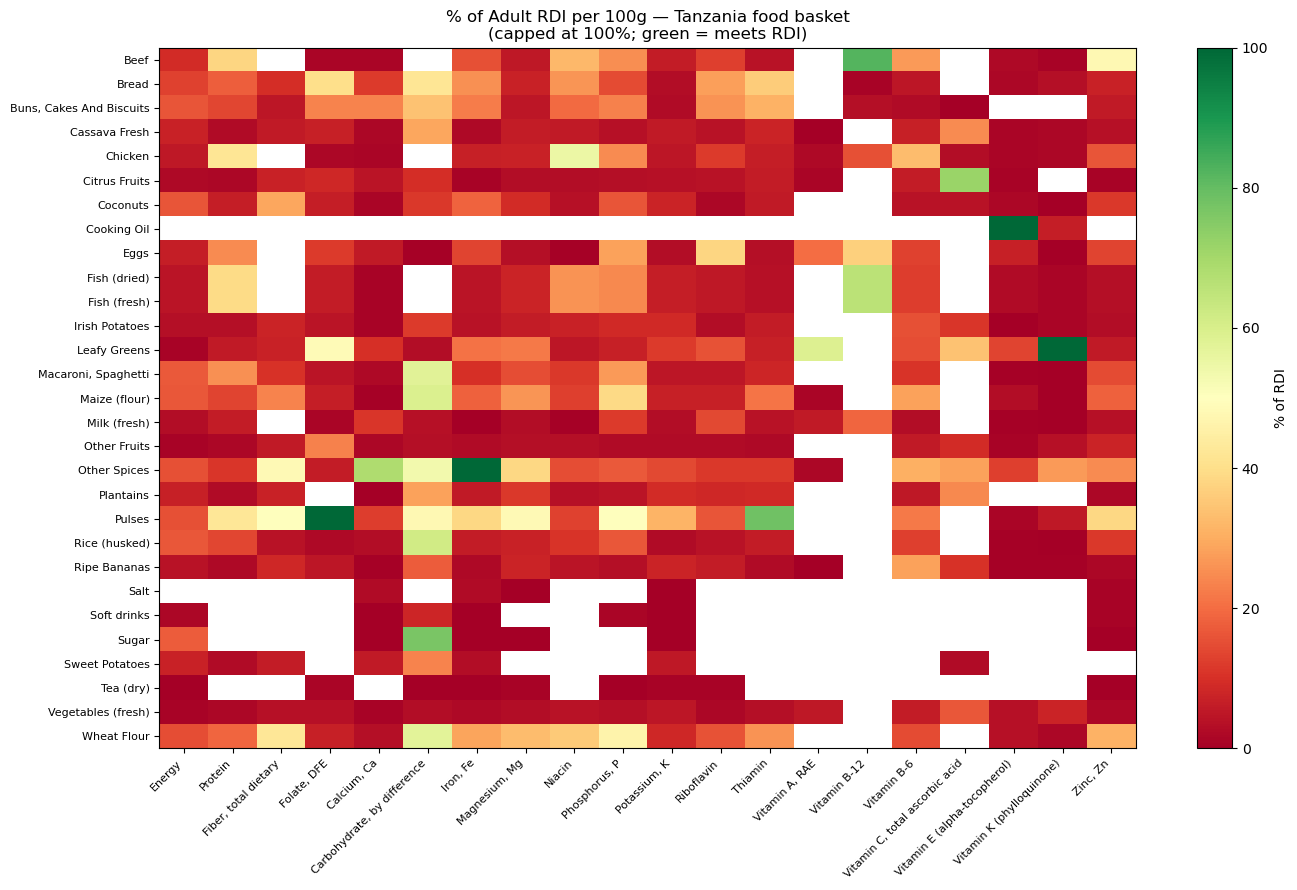

In [17]:
# nutritional gaps and heatmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Best single food for each nutrient across the whole basket
max_coverage = coverage_pct.max(axis=0)

gaps   = max_coverage[max_coverage <  20].sort_values()
strong = max_coverage[max_coverage >= 20].sort_values(ascending=False)

print("Nutrients with WEAK coverage (no single food provides ≥20% RDI per 100g):")
print(gaps.round(1).to_string())
print("\nNutrients with GOOD coverage (≥20% RDI from at least one food):")
print(strong.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 9))
data = coverage_pct[nutrient_cols].clip(upper=100)

im = ax.imshow(data.values, aspect='auto', cmap='RdYlGn',
               norm=mcolors.Normalize(vmin=0, vmax=100))

ax.set_xticks(range(len(nutrient_cols)))
ax.set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(data)))
ax.set_yticklabels(data.index, fontsize=8)
ax.set_title(
    '% of Adult RDI per 100g — Tanzania food basket\n(capped at 100%; green = meets RDI)',
    fontsize=12
)
plt.colorbar(im, ax=ax, label='% of RDI')
plt.tight_layout()
plt.savefig('tanzania_nutrient_coverage.png', dpi=150)
plt.show()

**Explanation:** While this heatmap is important to understand the landscape of foods and their nutritional content, it can be misleading. First of all, the 29 foods that survived to this point in the model are chosen because they have enough observations to be relevant, so more nutrient-dense foods could be excluded. Secondly, no singly food is meant to cover then entire RDI for a nutrient...a diet is supposed to include many of these foods.

## Nutritional Adequacy at the household level [B]

In [19]:
# Load prices w/both waves, take prices
p1 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2019-20)')
p2 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Prices (2020-21)')
prices = pd.concat([p1, p2], ignore_index=True)

# Convert prices to per gram
prices['price_per_g'] = prices['Price'] / 1000
price_map = (prices.groupby(['t', 'm', 'j'])['price_per_g']
                   .median()
                   .reset_index()
                   .set_index(['t', 'm', 'j'])['price_per_g'])

# Load food expenditures
x1 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2019-20)')
x2 = pd.read_excel('Tanzania.xlsx', sheet_name='Food Expenditures (2020-21)')
x_long = pd.concat([x1, x2], ignore_index=True)
for col in ['i', 't', 'm']:
    x_long[col] = x_long[col].astype(str)

# Keep only the 29 foods in the model (data consistency)
x_long = x_long[x_long['j'].isin(FOODS)]

x_long = x_long.join(price_map, on=['t', 'm', 'j'])

# If price is missing, use median
national_price = prices.groupby('j')['price_per_g'].median()
x_long['price_per_g'] = x_long['price_per_g'].fillna(x_long['j'].map(national_price))

# Grams purchased per recall period
x_long['grams'] = x_long['Expenditure'] / x_long['price_per_g']

# The survey recall period is 7 days —> convert to grams/day
RECALL_DAYS = 7
x_long['grams_per_day'] = x_long['grams'] / RECALL_DAYS

### Daily nutrient intake per household

In [21]:
# Nutrient content per gram (food_df is per 100g)
nutrients_per_g = food_nutrients / 100

# Map nutrient content onto expenditure rows
nutrient_cols = list(NUTRIENT_MAP.keys())
for col in nutrient_cols:
    x_long[col] = x_long['j'].map(nutrients_per_g[col])

# Nutrient intake per food per day = grams_per_day * nutrient_per_gram
intake_cols = []
for col in nutrient_cols:
    intake_col = f'intake_{col}'
    x_long[intake_col] = x_long['grams_per_day'] * x_long[col]
    intake_cols.append(intake_col)

# Get total daily nutrient intake per household
hh_intake = (x_long.groupby(['i', 't', 'm'])[intake_cols]
                    .sum()
                    .rename(columns=lambda c: c.replace('intake_', '')))

print(f"Households with valid nutrient intake estimates: {len(hh_intake):,}")
hh_intake.head()

Households with valid nutrient intake estimates: 1,514


,,,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,948.405485,55.039814,12.124776,519.066562,299.678951,166.504246,8.747810,296.061429,21.894047,576.957298,2857.665136,0.854640,0.639033,1067.113853,0.752185,1.683452,149.335656,29.917000,1010.634461,5.583126
0001-001-003,2019-20,Mainland Rural,1429.940668,61.317765,31.642736,783.618444,334.966837,260.674145,14.585679,487.338917,14.071520,1067.276263,3804.304737,0.861088,1.469207,841.532276,2.388210,1.750132,111.690977,29.530997,816.109557,10.824810
0001-001-004,2019-20,Dar Es Salaam,3902.832514,102.197695,57.225594,823.313470,655.066306,788.453060,21.811605,736.824094,21.300160,2338.074757,4665.526021,1.304956,2.700385,148.460048,2.580328,2.608212,33.681383,52.509963,25.384733,16.325350
0001-004-001,2019-20,Mainland Rural,4310.557553,109.114612,40.973798,284.250493,1034.420178,854.892000,16.081576,579.033847,19.340951,2179.460930,4063.657954,1.555924,1.495223,527.382082,3.592084,2.476382,33.191372,32.545339,243.453958,14.382199
0001-004-002,2019-20,Mainland Other Urban,32.284887,4.490080,1.809731,129.612136,69.786808,3.676331,1.901212,56.720283,1.130743,59.498352,471.532366,0.132559,0.067025,308.527936,0.187521,0.170107,22.527110,29.405601,307.885182,0.444872


### Household specific RDI targets

In [22]:
# Reload household characteristics (filtered to our two waves)
d_raw = pd.read_excel('Tanzania.xlsx', sheet_name='Household Characteristics')
d_hh = d_raw[d_raw['t'].isin(['2019-20', '2020-21'])].copy()
for col in ['i', 't', 'm']:
    d_hh[col] = d_hh[col].astype(str)
d_hh = d_hh.set_index(['i', 't', 'm']).fillna(0)


rdi = pd.read_csv('diet_minimums.csv', index_col=0)
rdi = rdi.set_index('Nutrition').drop(columns='Source')
rdi = rdi.apply(pd.to_numeric, errors='coerce')

# Map demographic columns in d_hh to RDI columns
DEMO_TO_RDI = {
    'Males 00-03':   'C 1-3',
    'Females 00-03': 'C 1-3',
    'Males 04-08':   'M 4-8',
    'Females 04-08': 'F 4-8',
    'Males 09-13':   'M 9-13',
    'Females 09-13': 'F 9-13',
    'Males 14-18':   'M 14-18',
    'Females 14-18': 'F 14-18',
    'Males 19-30':   'M 19-30',
    'Females 19-30': 'F 19-30',
    'Males 31-50':   'M 31-50',
    'Females 31-50': 'F 31-50',
    'Males 51-99':   'M 51+',
    'Females 51-99': 'F 51+',
}

# For each household, RDI_hh = sum over members of (n_members_in_group * RDI_for_group)
demo_cols = [c for c in DEMO_TO_RDI if c in d_hh.columns]

rdi_hh = pd.DataFrame(index=d_hh.index, columns=nutrient_cols, dtype=float)
rdi_hh[:] = 0.0

for demo_col in demo_cols:
    rdi_col = DEMO_TO_RDI[demo_col]
    if rdi_col not in rdi.columns:
        continue
    # n_members in this group for each household (shape: n_households)
    n_members = d_hh[demo_col]
    # RDI for this group for each nutrient (shape: n_nutrients)
    rdi_for_group = rdi[rdi_col]
    # Outer product: each household's contribution from this demographic group
    contribution = pd.DataFrame(
        np.outer(n_members.values, rdi_for_group.values),
        index=n_members.index,
        columns=rdi_for_group.index
    )
    rdi_hh = rdi_hh.add(contribution.reindex(columns=nutrient_cols), fill_value=0)

rdi_hh = rdi_hh.apply(pd.to_numeric)
print(f"Household RDI targets computed for {len(rdi_hh):,} households")
rdi_hh.head()

Household RDI targets computed for 5,893 households


,,,Energy,Protein,"Fiber, total dietary","Folate, DFE","Calcium, Ca","Carbohydrate, by difference","Iron, Fe","Magnesium, Mg",Niacin,"Phosphorus, P","Potassium, K",Riboflavin,Thiamin,"Vitamin A, RAE",Vitamin B-12,Vitamin B-6,"Vitamin C, total ascorbic acid",Vitamin E (alpha-tocopherol),Vitamin K (phylloquinone),"Zinc, Zn"
i,t,m,,,,,,,,,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,3600.0,102.0,50.4,800.0,2200.0,260.0,16.0,740.0,30.0,1400.0,9400.0,2.4,2.3,1600.0,4.8,3.2,165.0,30.0,210.0,19.0
0001-001-003,2019-20,Mainland Rural,2200.0,56.0,30.8,400.0,1000.0,130.0,8.0,420.0,16.0,700.0,4700.0,1.3,1.2,900.0,2.4,1.3,90.0,15.0,120.0,11.0
0001-001-004,2019-20,Dar Es Salaam,2400.0,56.0,33.6,400.0,1000.0,130.0,8.0,400.0,16.0,700.0,4700.0,1.3,1.2,900.0,2.4,1.3,90.0,15.0,120.0,11.0
0001-004-001,2019-20,Mainland Rural,5400.0,115.0,75.6,950.0,2700.0,390.0,33.0,790.0,36.0,1860.0,12400.0,2.9,2.8,1900.0,5.7,3.1,180.0,36.0,240.0,22.0
0001-004-002,2019-20,Mainland Other Urban,2000.0,46.0,28.0,400.0,1000.0,130.0,18.0,310.0,14.0,700.0,4700.0,1.1,1.1,700.0,2.4,1.3,75.0,15.0,90.0,8.0


### Compare intake to RDI and evaluate adequacy

In [26]:
# Align households with expenditure and demographic data
common_idx = hh_intake.index.intersection(rdi_hh.index)
intake_aligned = hh_intake.loc[common_idx, nutrient_cols]
rdi_aligned    = rdi_hh.loc[common_idx, nutrient_cols]

print(f"Households in joint sample: {len(common_idx):,}")

# Adequacy ratio: intake / household RDI (>1 means household meets its target)
adequacy = intake_aligned / rdi_aligned

# Proportion of households meeting RDI for each nutrient
meets_rdi = (adequacy >= 1.0).mean() * 100  # percent

print("% of households meeting household RDI")
print(meets_rdi.sort_values().round(1).to_string())

Households in joint sample: 1,514
% of households meeting household RDI
Calcium, Ca                        2.2
Vitamin A, RAE                    12.0
Potassium, K                      13.0
Vitamin B-12                      17.2
Riboflavin                        22.9
Vitamin C, total ascorbic acid    30.8
Niacin                            34.7
Vitamin E (alpha-tocopherol)      43.4
Energy                            43.9
Zinc, Zn                          46.7
Iron, Fe                          49.5
Folate, DFE                       55.2
Protein                           56.5
Fiber, total dietary              56.6
Thiamin                           58.4
Vitamin B-6                       61.9
Magnesium, Mg                     63.1
Vitamin K (phylloquinone)         64.1
Phosphorus, P                     67.3
Carbohydrate, by difference       91.5


Adequacy summary
                                pct_meeting_RDI  median_adequacy  pct_below_half_RDI
Calcium, Ca                                 2.2             0.22                87.0
Vitamin A, RAE                             12.0             0.29                69.0
Potassium, K                               13.0             0.52                47.6
Vitamin B-12                               17.2             0.35                60.6
Riboflavin                                 22.9             0.60                38.4
Vitamin C, total ascorbic acid             30.8             0.60                42.4
Niacin                                     34.7             0.81                21.4
Vitamin E (alpha-tocopherol)               43.4             0.89                26.0
Energy                                     43.9             0.92                14.9
Zinc, Zn                                   46.7             0.95                15.6
Iron, Fe                                   49.5 

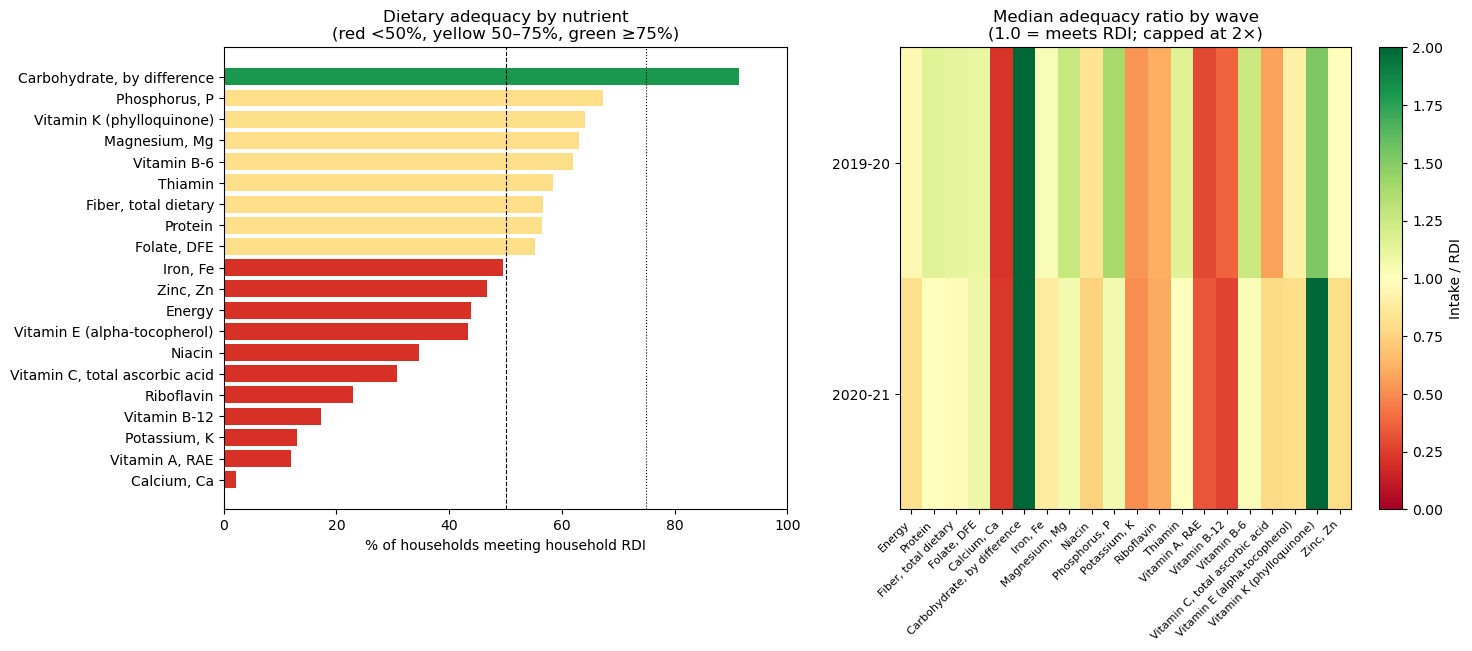

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of % households meeting RDI
meets_sorted = meets_rdi.sort_values()
colors = ['#d73027' if v < 50 else '#fee08b' if v < 75 else '#1a9850'
          for v in meets_sorted]
axes[0].barh(meets_sorted.index, meets_sorted.values, color=colors)
axes[0].axvline(50, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(75, color='black', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('% of households meeting household RDI')
axes[0].set_title('Dietary adequacy by nutrient\n(red <50%, yellow 50–75%, green ≥75%)')
axes[0].set_xlim(0, 100)

# Right: heatmap of median adequacy ratio by nutrient and survey wave
adequacy_wave = adequacy.reset_index()
med_by_wave = (adequacy_wave.groupby('t')[nutrient_cols]
                             .median()
                             .clip(upper=2))

im = axes[1].imshow(med_by_wave.values, aspect='auto', cmap='RdYlGn',
                    norm=mcolors.Normalize(vmin=0, vmax=2))
axes[1].set_xticks(range(len(nutrient_cols)))
axes[1].set_xticklabels(nutrient_cols, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(len(med_by_wave)))
axes[1].set_yticklabels(med_by_wave.index)
axes[1].set_title('Median adequacy ratio by wave\n(1.0 = meets RDI; capped at 2×)')
plt.colorbar(im, ax=axes[1], label='Intake / RDI')

# Summary table
summary = pd.DataFrame({
    'pct_meeting_RDI':    meets_rdi.round(1),
    'median_adequacy':    adequacy.median().round(2),
    'pct_below_half_RDI': ((adequacy < 0.5).mean() * 100).round(1),
}).sort_values('pct_meeting_RDI')

print("Adequacy summary")
print(summary.to_string())

Here we see the % of Households that actually meet the recommended dietary intakes that we outlined earlier. The graph shows the percentage of households meeting the household RDI on the x-axis with the specific nutrient on the y-axis. The exact values are shown in the table in the top right.

The heatmap shows not just whether households meet requirements, but how far they are from them. An interesting trend appears in that several RDIs move from slightly green to yellowish from the first wave to the second. You would expect nutritional outcomes to increase over time, not regress. This is very likely due to the COVID-19 pandemic. From 2019-2020, COVID had not yet reached Tanzania; but in the subsequent years, the pandemic had a huge impact: disrupting supply chains, the tourism industry, and dramatically lowering income and purchasing power.